<a href="https://colab.research.google.com/github/Anantha-padmanabha-001/MlOps-Assignment-1/blob/main/mlops_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries imported successfully!
✅ Dataset loaded successfully!
   Shape: (303, 14)  →  303 patients, 14 columns

========== FIRST 5 ROWS ==========
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 

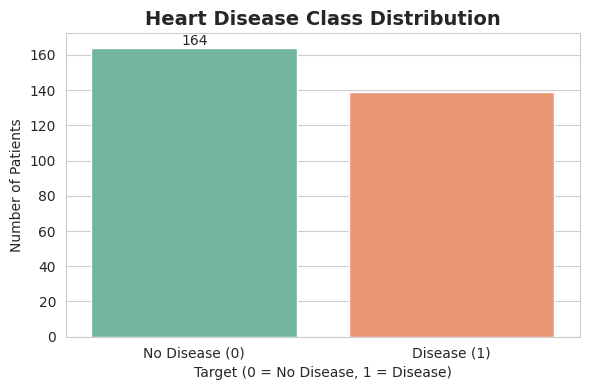

→ The dataset is fairly balanced: good for classification.


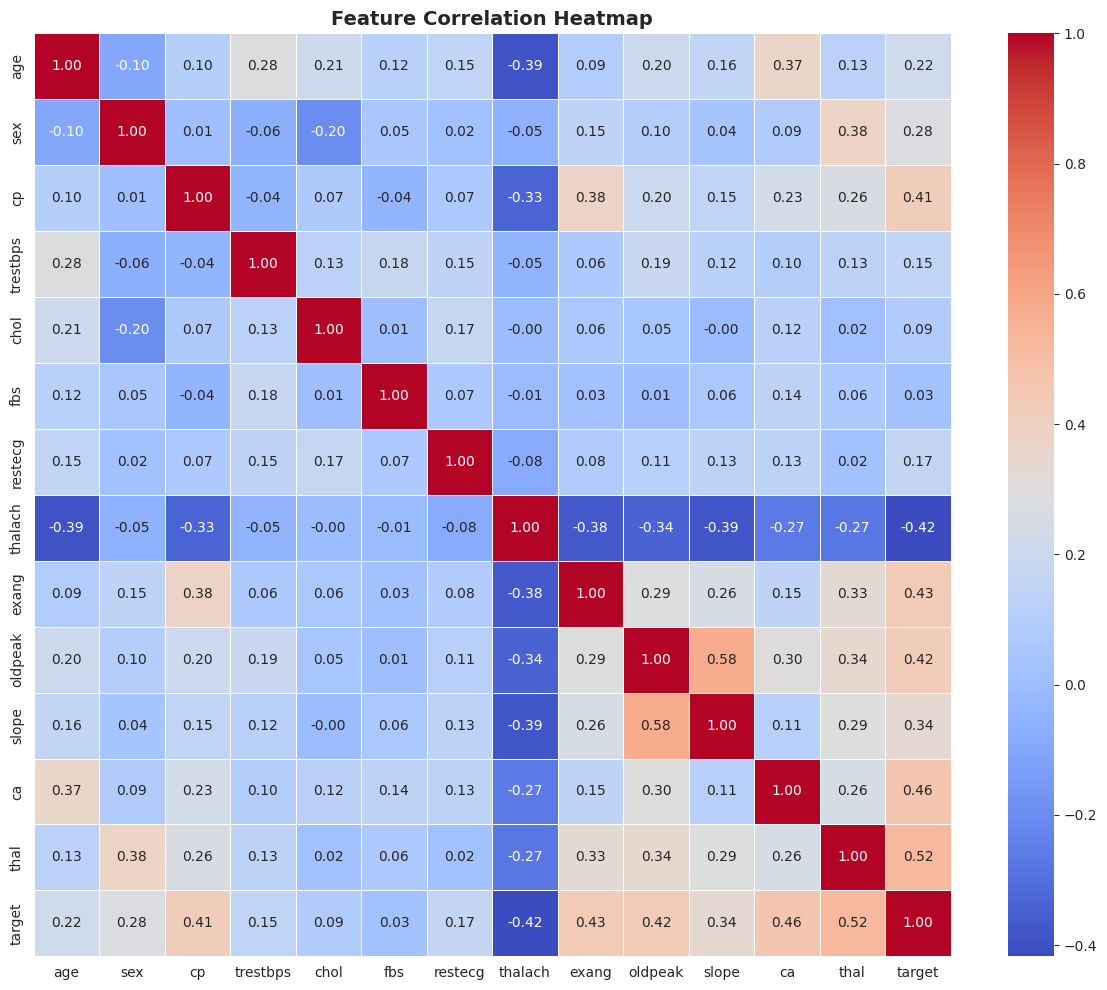

→ Key finding: 'cp', 'thalach', 'exang', 'oldpeak' are strongly correlated with target.


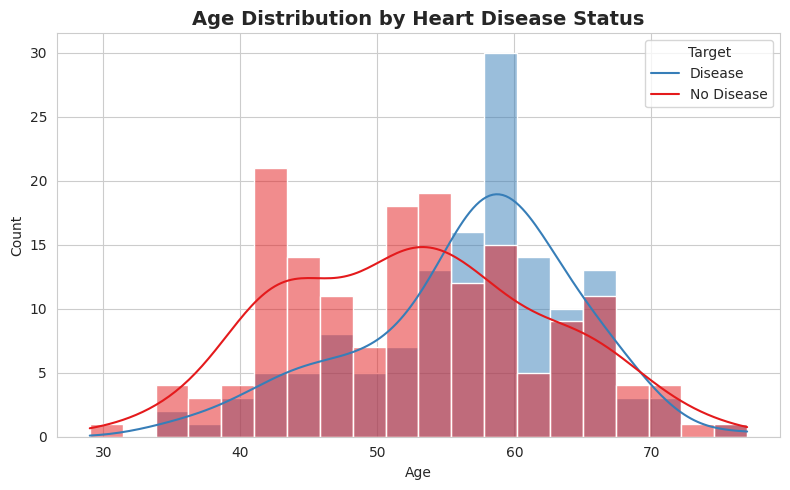

→ Heart disease is more common in older patients (ages 50-65).


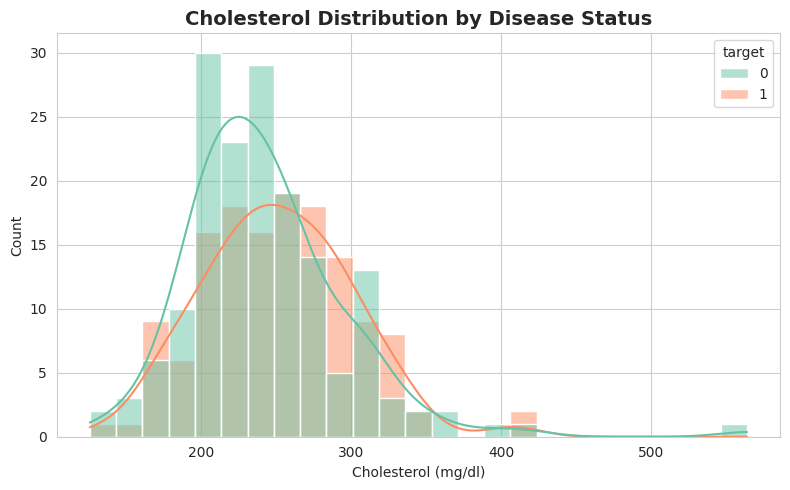

→ Cholesterol alone is not a strong predictor in this dataset.


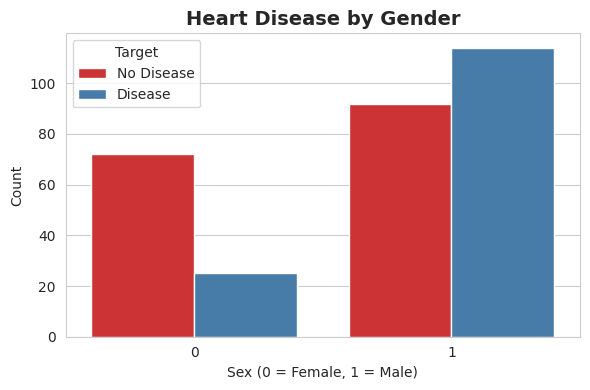

→ Males have significantly higher rate of heart disease in this dataset.


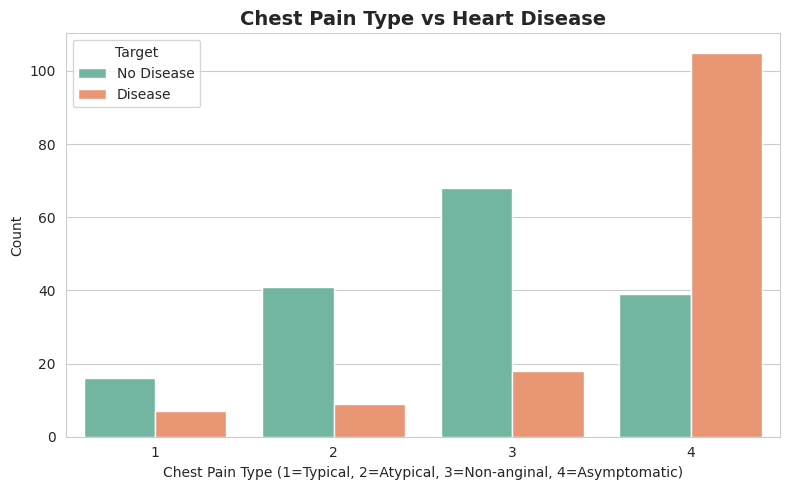

→ Asymptomatic chest pain (type 4) strongly associated with heart disease.


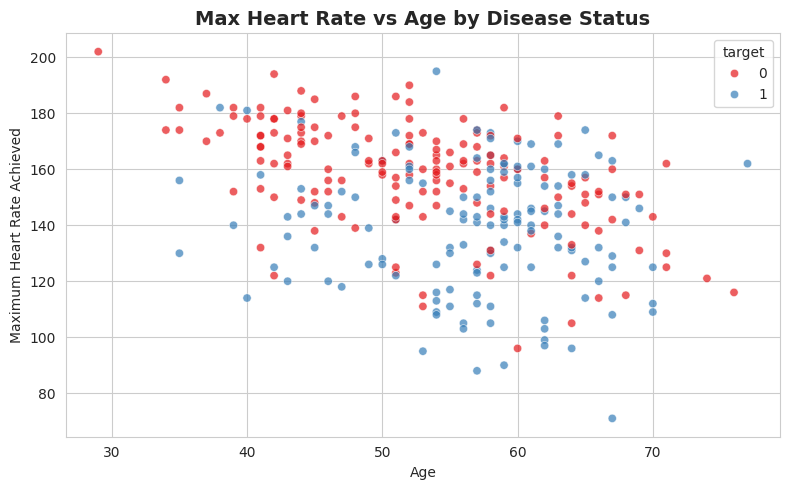

→ Patients with disease tend to have lower max heart rate for their age.


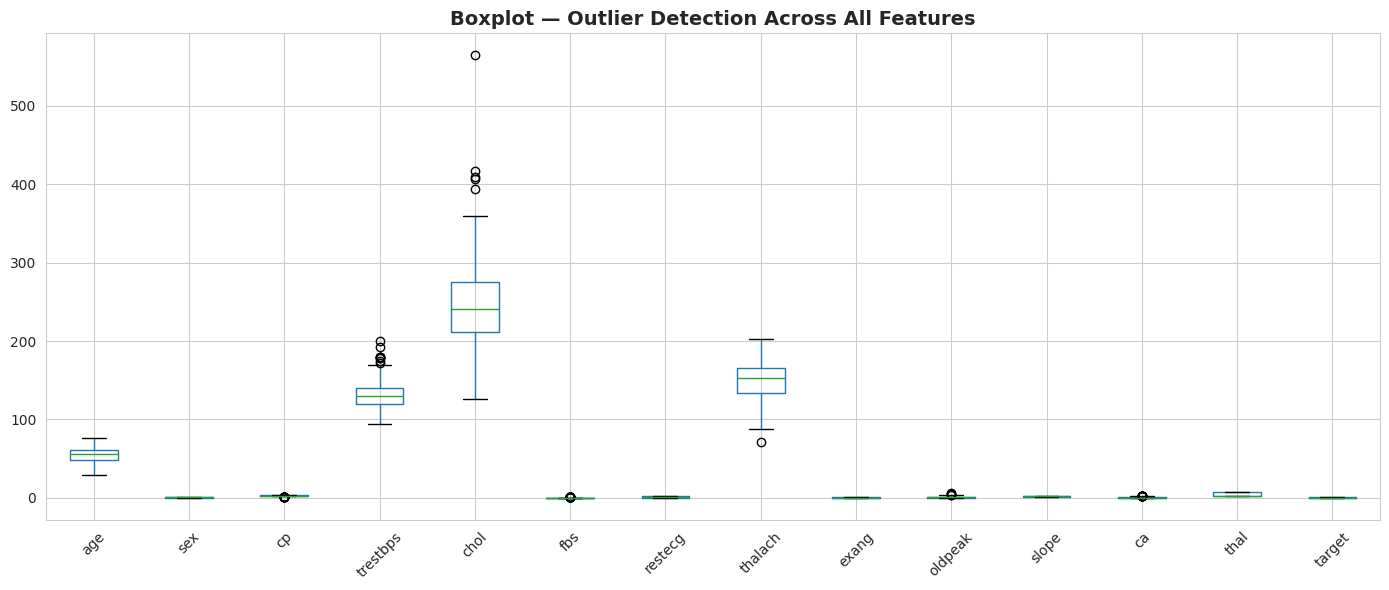

→ 'chol' and 'trestbps' contain some outliers but we retain them (medical data).

=============== PHASE 1 COMPLETE ✅ ===============
EDA done: 8 visualizations generated, dataset cleaned and saved.

========== FEATURES USED FOR TRAINING ==========
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Total samples: 303
Total features: 13

Training samples : 242
Testing samples  : 61

✅ Feature engineering complete!

  MODEL: Logistic Regression
  Accuracy  : 0.8689
  Precision : 0.8125
  Recall    : 0.9286
  ROC-AUC   : 0.9513
  CV ROC-AUC: 0.8960 (+/- 0.0148)

  Classification Report:

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


  MODEL: Random Fo

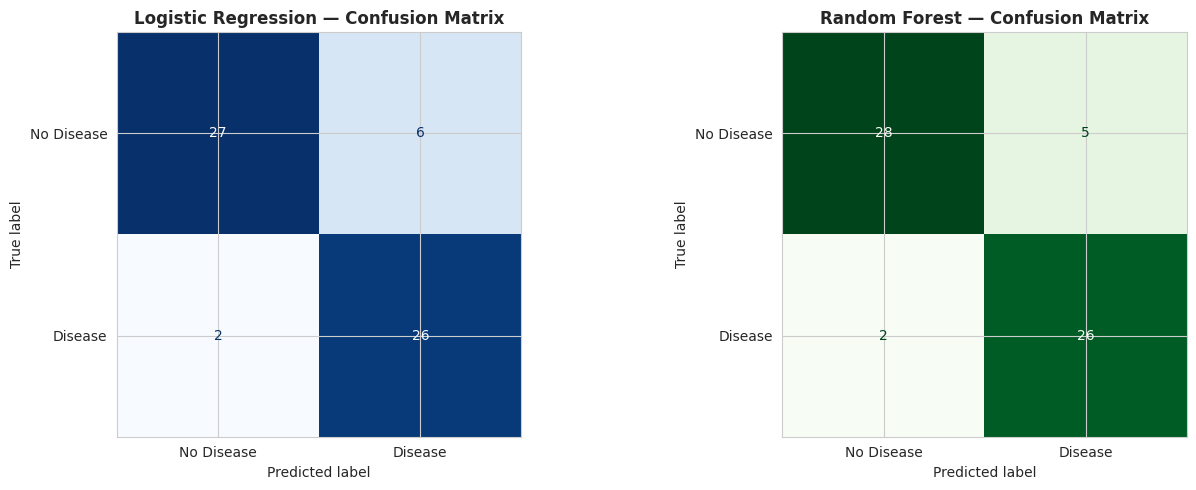

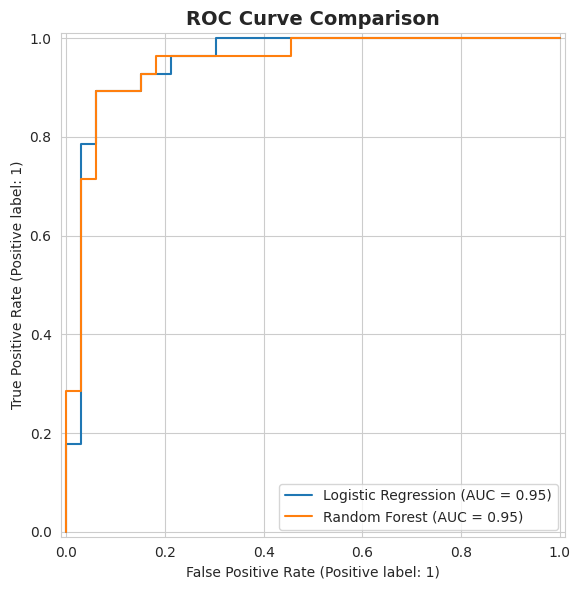

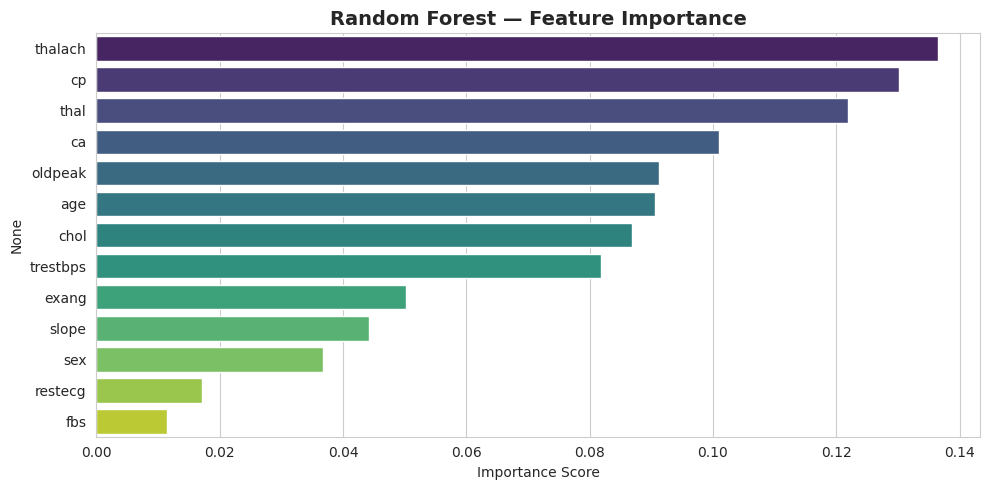

→ Top predictors: cp, thalach, ca, oldpeak, thal

✅ Model saved as 'heart_disease_model.pkl'
✅ Feature columns saved as 'feature_columns.pkl'

   Quick verification — predictions on 3 test samples: [0 1 0]
   ✅ Model loads and predicts correctly!

✅ requirements.txt written!

  PHASE 1 & 2 COMPLETE ✅
  Files saved:
    → heart_disease_cleaned.csv
    → heart_disease_model.pkl
    → feature_columns.pkl
    → requirements.txt
    → 10 plot PNG files


In [ ]:
# =============================================================
# MLOps Assignment 1 - Heart Disease Prediction
# BITS Pilani | AIMLCZG523
# Phase 1: Data Acquisition & EDA
# Phase 2: Feature Engineering & Model Development
# =============================================================


# =============================================================
# SECTION 1: INSTALL & IMPORT LIBRARIES
# =============================================================

# Install the UCI dataset downloader (only needed in Colab)
# !pip install ucimlrepo -q
!pip install ucimlrepo -q

# pandas  -> loading and manipulating data tables
import pandas as pd

# numpy -> numerical calculations
import numpy as np

# matplotlib & seaborn -> creating visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn -> machine learning models and utilities
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")


# =============================================================
# SECTION 2: LOAD DATASET
# =============================================================
# We use the UCI ML Repository to download the Heart Disease dataset.
# This is the official Cleveland dataset with 303 patients and 14 features.

from ucimlrepo import fetch_ucirepo

# Fetch dataset by its UCI ID (45 = Heart Disease)
heart_disease = fetch_ucirepo(id=45)

# Combine features (X) and target (y) into one dataframe
df = pd.concat([heart_disease.data.features,
                heart_disease.data.targets], axis=1)

# Rename the target column clearly
df.columns = [*heart_disease.data.features.columns, 'target']

print("✅ Dataset loaded successfully!")
print(f"   Shape: {df.shape}  →  {df.shape[0]} patients, {df.shape[1]} columns")


# =============================================================
# SECTION 3: INITIAL DATA INSPECTION
# =============================================================

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== BASIC STATISTICS ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())
# Note: 'ca' has 4 missing values, 'thal' has 2 — we will handle these below


# =============================================================
# SECTION 4: DATA CLEANING
# =============================================================

# --- 4a. Convert target to BINARY classification ---
# Original target: 0 = no disease, 1/2/3/4 = varying severity of disease
# For binary classification: 0 = no disease, 1 = disease (any severity)
df['target'] = (df['target'] > 0).astype(int)

print("\n========== TARGET AFTER BINARY CONVERSION ==========")
print(df['target'].value_counts())
print("  0 = No Heart Disease")
print("  1 = Heart Disease Present")

# --- 4b. Handle missing values ---
# 'ca' and 'thal' have a small number of missing values.
# We fill them with the median (middle value) of each column —
# this is safer than dropping rows when we have a small dataset.
df['ca'].fillna(df['ca'].median(), inplace=True)
df['thal'].fillna(df['thal'].median(), inplace=True)

print("\n========== MISSING VALUES AFTER CLEANING ==========")
print(df.isnull().sum())
# All should now show 0

# --- 4c. Remove duplicate rows (if any) ---
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"\n========== DUPLICATES REMOVED: {before - after} rows ==========")
print(f"   Final dataset shape: {df.shape}")

# --- 4d. Save cleaned dataset ---
df.to_csv('heart_disease_cleaned.csv', index=False)
print("\n✅ Cleaned dataset saved as 'heart_disease_cleaned.csv'")


# =============================================================
# SECTION 5: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================

# --- Plot 1: Class Distribution ---
# Shows how balanced the dataset is between disease / no disease
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df, palette='Set2')
ax.bar_label(ax.containers[0])  # Add count labels on bars
plt.title("Heart Disease Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ['No Disease (0)', 'Disease (1)'])
plt.tight_layout()
plt.savefig('plot_class_distribution.png')
plt.show()
print("→ The dataset is fairly balanced: good for classification.")

# --- Plot 2: Correlation Heatmap ---
# Shows how strongly each feature relates to the others and to the target
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png')
plt.show()
print("→ Key finding: 'cp', 'thalach', 'exang', 'oldpeak' are strongly correlated with target.")

# --- Plot 3: Age Distribution by Disease Status ---
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True, palette='Set1')
plt.title("Age Distribution by Heart Disease Status", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(title='Target', labels=['Disease', 'No Disease'])
plt.tight_layout()
plt.savefig('plot_age_distribution.png')
plt.show()
print("→ Heart disease is more common in older patients (ages 50-65).")

# --- Plot 4: Cholesterol Distribution ---
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='chol', hue='target', bins=25, kde=True, palette='Set2')
plt.title("Cholesterol Distribution by Disease Status", fontsize=14, fontweight='bold')
plt.xlabel("Cholesterol (mg/dl)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('plot_cholesterol_distribution.png')
plt.show()
print("→ Cholesterol alone is not a strong predictor in this dataset.")

# --- Plot 5: Heart Disease by Gender ---
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', hue='target', data=df, palette='Set1')
plt.title("Heart Disease by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.savefig('plot_gender_distribution.png')
plt.show()
print("→ Males have significantly higher rate of heart disease in this dataset.")

# --- Plot 6: Chest Pain Type vs Heart Disease ---
plt.figure(figsize=(8, 5))
sns.countplot(x='cp', hue='target', data=df, palette='Set2')
plt.title("Chest Pain Type vs Heart Disease", fontsize=14, fontweight='bold')
plt.xlabel("Chest Pain Type (1=Typical, 2=Atypical, 3=Non-anginal, 4=Asymptomatic)")
plt.ylabel("Count")
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.savefig('plot_chest_pain.png')
plt.show()
print("→ Asymptomatic chest pain (type 4) strongly associated with heart disease.")

# --- Plot 7: Max Heart Rate vs Age (coloured by disease) ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='Set1', alpha=0.7)
plt.title("Max Heart Rate vs Age by Disease Status", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate Achieved")
plt.tight_layout()
plt.savefig('plot_heartrate_vs_age.png')
plt.show()
print("→ Patients with disease tend to have lower max heart rate for their age.")

# --- Plot 8: Boxplot for Outlier Detection ---
plt.figure(figsize=(14, 6))
df.boxplot(figsize=(14, 6))
plt.title("Boxplot — Outlier Detection Across All Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_boxplot_outliers.png')
plt.show()
print("→ 'chol' and 'trestbps' contain some outliers but we retain them (medical data).")

print("\n=============== PHASE 1 COMPLETE ✅ ===============")
print("EDA done: 8 visualizations generated, dataset cleaned and saved.")


# =============================================================
# SECTION 6: FEATURE ENGINEERING
# =============================================================
# Prepare features (X) and target (y) for model training

# Load the cleaned dataset
df = pd.read_csv('heart_disease_cleaned.csv')

# Separate features from target
X = df.drop('target', axis=1)   # All columns except target
y = df['target']                 # Only the target column

print("\n========== FEATURES USED FOR TRAINING ==========")
print(list(X.columns))
print(f"\nTotal samples: {X.shape[0]}")
print(f"Total features: {X.shape[1]}")

# --- Split into training (80%) and testing (20%) sets ---
# random_state=42 ensures we get the same split every time (reproducibility)
# stratify=y ensures both splits have similar class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

print("\n✅ Feature engineering complete!")


# =============================================================
# SECTION 7: MODEL TRAINING & EVALUATION
# =============================================================
# We train two models and compare their performance.
# Using sklearn Pipelines ensures scaling is applied correctly
# inside cross-validation (prevents data leakage).

# --- Cross-validation setup ---
# StratifiedKFold preserves class balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Helper function to print all metrics clearly
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, cv):
    # Train the model
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]  # Probability of disease

    # Cross-validation score
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='roc_auc')

    print(f"\n{'='*50}")
    print(f"  MODEL: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy_score(y_te, preds):.4f}")
    print(f"  Precision : {precision_score(y_te, preds):.4f}")
    print(f"  Recall    : {recall_score(y_te, preds):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_te, proba):.4f}")
    print(f"  CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_te, preds, target_names=['No Disease', 'Disease']))

    return model, preds, proba


# --- Model 1: Logistic Regression ---
# Uses a Pipeline: StandardScaler (normalizes features) → LogisticRegression
# Scaling is important for Logistic Regression as it is sensitive to feature magnitudes
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),          # Normalize all features to same scale
    ('model', LogisticRegression(          # Logistic Regression classifier
        max_iter=1000,                     # Allow enough iterations to converge
        random_state=42
    ))
])

lr_model, lr_preds, lr_proba = evaluate_model(
    "Logistic Regression",
    lr_pipeline, X_train, X_test, y_train, y_test, cv
)


# --- Model 2: Random Forest ---
# Random Forest does NOT need scaling (tree-based model)
# It builds many decision trees and combines their votes
rf_model_obj = RandomForestClassifier(
    n_estimators=100,    # Number of trees
    max_depth=10,        # Limit tree depth to prevent overfitting
    random_state=42
)

rf_model, rf_preds, rf_proba = evaluate_model(
    "Random Forest",
    rf_model_obj, X_train, X_test, y_train, y_test, cv
)


# =============================================================
# SECTION 8: MODEL COMPARISON VISUALIZATIONS
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix — Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds,
    display_labels=['No Disease', 'Disease'],
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title("Logistic Regression — Confusion Matrix", fontweight='bold')

# Confusion Matrix — Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds,
    display_labels=['No Disease', 'Disease'],
    ax=axes[1], colorbar=False, cmap='Greens'
)
axes[1].set_title("Random Forest — Confusion Matrix", fontweight='bold')

plt.tight_layout()
plt.savefig('plot_confusion_matrices.png')
plt.show()

# ROC Curves — both models on same plot
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, lr_proba, name="Logistic Regression", ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=plt.gca())
plt.title("ROC Curve Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_roc_curves.png')
plt.show()

# Feature Importance — Random Forest only (not available for LR in same way)
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title("Random Forest — Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig('plot_feature_importance.png')
plt.show()
print("→ Top predictors: cp, thalach, ca, oldpeak, thal")


# =============================================================
# SECTION 9: SAVE FINAL MODEL
# =============================================================
# We save the best model (Random Forest) using pickle.
# This allows us to load it later for the API without retraining.

# Save Random Forest model
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save the feature column names (needed during API inference)
feature_columns = list(X.columns)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("\n✅ Model saved as 'heart_disease_model.pkl'")
print("✅ Feature columns saved as 'feature_columns.pkl'")

# Verify model loads correctly
with open('heart_disease_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_test[:3])
print(f"\n   Quick verification — predictions on 3 test samples: {test_pred}")
print("   ✅ Model loads and predicts correctly!")


# =============================================================
# SECTION 10: WRITE REQUIREMENTS FILE
# =============================================================
# This lists all Python libraries needed to reproduce this work

requirements = """pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
ucimlrepo>=0.0.3
mlflow>=2.9.0
fastapi>=0.104.0
uvicorn>=0.24.0
pickle-mixin>=1.0.2
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("\n✅ requirements.txt written!")

print("\n" + "="*55)
print("  PHASE 1 & 2 COMPLETE ✅")
print("  Files saved:")
print("    → heart_disease_cleaned.csv")
print("    → heart_disease_model.pkl")
print("    → feature_columns.pkl")
print("    → requirements.txt")
print("    → 10 plot PNG files")
print("="*55)

In [ ]:
# =============================================================
# PHASE 3 - EXPERIMENT TRACKING WITH MLFLOW
# =============================================================
# MLflow records every training run — parameters, metrics, and
# the model itself — so experiments are fully reproducible.

!pip install mlflow -q

import mlflow
import mlflow.sklearn

# =============================================================
# SECTION 1: SETUP MLFLOW EXPERIMENT
# =============================================================

# Name our experiment — all runs will be grouped under this
mlflow.set_experiment("Heart_Disease_Prediction")

print("✅ MLflow experiment set up!")

# =============================================================
# SECTION 2: LOG LOGISTIC REGRESSION RUN
# =============================================================

with mlflow.start_run(run_name="Logistic_Regression"):

    # --- Train model ---
    lr = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ])
    lr.fit(X_train, y_train)
    preds_lr = lr.predict(X_test)
    proba_lr = lr.predict_proba(X_test)[:, 1]

    # --- Log parameters (settings used) ---
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)

    # --- Log metrics (results) ---
    mlflow.log_metric("accuracy",  accuracy_score(y_test, preds_lr))
    mlflow.log_metric("precision", precision_score(y_test, preds_lr))
    mlflow.log_metric("recall",    recall_score(y_test, preds_lr))
    mlflow.log_metric("roc_auc",   roc_auc_score(y_test, proba_lr))

    # --- Log the model itself ---
    mlflow.sklearn.log_model(lr, "logistic_regression_model")

    # --- Log plots as artifacts ---
    mlflow.log_artifact("plot_roc_curves.png")
    mlflow.log_artifact("plot_confusion_matrices.png")

    print("✅ Logistic Regression run logged to MLflow!")

# =============================================================
# SECTION 3: LOG RANDOM FOREST RUN
# =============================================================

with mlflow.start_run(run_name="Random_Forest"):

    # --- Train model ---
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    preds_rf = rf.predict(X_test)
    proba_rf = rf.predict_proba(X_test)[:, 1]

    # --- Log parameters ---
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)

    # --- Log metrics ---
    mlflow.log_metric("accuracy",  accuracy_score(y_test, preds_rf))
    mlflow.log_metric("precision", precision_score(y_test, preds_rf))
    mlflow.log_metric("recall",    recall_score(y_test, preds_rf))
    mlflow.log_metric("roc_auc",   roc_auc_score(y_test, proba_rf))

    # --- Log model and artifacts ---
    mlflow.sklearn.log_model(rf, "random_forest_model")
    mlflow.log_artifact("plot_feature_importance.png")
    mlflow.log_artifact("heart_disease_cleaned.csv")

    print("✅ Random Forest run logged to MLflow!")

# =============================================================
# SECTION 4: VIEW RESULTS
# =============================================================

# Load and display all runs from this experiment
runs = mlflow.search_runs(experiment_names=["Heart_Disease_Prediction"])

print("\n========== MLFLOW EXPERIMENT RESULTS ==========")
print(runs[['run_id', 'tags.mlflow.runName',
            'metrics.accuracy', 'metrics.precision',
            'metrics.recall', 'metrics.roc_auc']].to_string(index=False))

print("\n=============== PHASE 3 COMPLETE ✅ ===============")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

2026/05/24 17:38:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/24 17:38:09 INFO mlflow.store.db.utils: Updating database tables
2026/05/24 17:38:12 INFO mlflow.tracking.fluent: Experiment with name 'Heart_Disease_Prediction' does not exist. Creating a new experiment.


✅ MLflow experiment set up!


2026/05/24 17:38:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:38:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logistic Regression run logged to MLflow!


2026/05/24 17:38:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:38:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest run logged to MLflow!

========== MLFLOW EXPERIMENT RESULTS ==========
                          run_id tags.mlflow.runName  metrics.accuracy  metrics.precision  metrics.recall  metrics.roc_auc
9c55675ebb3749719bfe009b6a1c2d99       Random_Forest          0.885246            0.83871        0.928571         0.948052
d97b0accddf741b48590fb1d2614de72 Logistic_Regression          0.868852            0.81250        0.928571         0.951299

=============== PHASE 3 COMPLETE ✅ ===============


In [ ]:
# =============================================================
# PHASE 4 - MODEL PACKAGING & REPRODUCIBILITY
# =============================================================
# We package the model + preprocessing pipeline together so
# anyone can load it and get predictions without retraining.

import pickle
import os

# =============================================================
# SECTION 1: SAVE FULL PIPELINE (Scaler + Model together)
# =============================================================
# We save the ENTIRE pipeline — scaler + logistic regression
# and the random forest separately.
# This ensures preprocessing is always applied correctly.

# Save Logistic Regression pipeline (includes scaler inside)
with open('lr_pipeline.pkl', 'wb') as f:
    pickle.dump(lr, f)
print("✅ Logistic Regression pipeline saved as 'lr_pipeline.pkl'")

# Save Random Forest model
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("✅ Random Forest model saved as 'heart_disease_model.pkl'")

# Save feature column names
feature_columns = list(X_train.columns)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print("✅ Feature columns saved as 'feature_columns.pkl'")

# =============================================================
# SECTION 2: VERIFY MODEL LOADS CORRECTLY
# =============================================================
# Simulate loading the model fresh (as the API would do)

with open('heart_disease_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('feature_columns.pkl', 'rb') as f:
    loaded_features = pickle.load(f)

# Run a test prediction using first 3 rows of test set
sample = X_test[:3]
predictions = loaded_model.predict(sample)
probabilities = loaded_model.predict_proba(sample)[:, 1]

print("\n========== MODEL VERIFICATION ==========")
print(f"Feature columns: {loaded_features}")
print(f"Sample predictions : {predictions}")
print(f"Disease probability: {[round(p, 3) for p in probabilities]}")
print("✅ Model loads and predicts correctly!")

# =============================================================
# SECTION 3: WRITE REQUIREMENTS.TXT
# =============================================================

requirements = """pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
ucimlrepo>=0.0.3
mlflow>=2.9.0
fastapi>=0.104.0
uvicorn>=0.24.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("\n✅ requirements.txt written!")

# =============================================================
# SECTION 4: LIST ALL SAVED FILES
# =============================================================

print("\n========== ALL SAVED FILES ==========")
saved_files = [
    'heart_disease_cleaned.csv',
    'heart_disease_model.pkl',
    'lr_pipeline.pkl',
    'feature_columns.pkl',
    'requirements.txt'
]
for file in saved_files:
    exists = "✅" if os.path.exists(file) else "❌ MISSING"
    print(f"  {exists}  {file}")

print("\n=============== PHASE 4 COMPLETE ✅ ===============")

✅ Logistic Regression pipeline saved as 'lr_pipeline.pkl'
✅ Random Forest model saved as 'heart_disease_model.pkl'
✅ Feature columns saved as 'feature_columns.pkl'

========== MODEL VERIFICATION ==========
Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Sample predictions : [0 1 0]
Disease probability: [np.float64(0.262), np.float64(0.693), np.float64(0.065)]
✅ Model loads and predicts correctly!

✅ requirements.txt written!

========== ALL SAVED FILES ==========
  ✅  heart_disease_cleaned.csv
  ✅  heart_disease_model.pkl
  ✅  lr_pipeline.pkl
  ✅  feature_columns.pkl
  ✅  requirements.txt

=============== PHASE 4 COMPLETE ✅ ===============
